In [ ]:
import pandas as pd
df = pd.read_csv('/content/diabetes_012_health_indicators_BRFSS2015.csv')
print(df.head())
print(df.shape)
print("--- Info ---")
print(df.info())
print("\n--- Target Variable Distribution (Diabetes_012) ---")
print(df['Diabetes_012'].value_counts(normalize=True))
print(df['Diabetes_012'].value_counts())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler


try:
    df = pd.read_csv('/content/diabetes_012_health_indicators_BRFSS2015.csv')
    print("Dataset loaded successfully!")
    print(f"Original shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Please upload the CSV to Colab.")

df['Diabetes_binary'] = df['Diabetes_012'].replace({2.0: 1.0, 1.0: 1.0})
df = df.drop('Diabetes_012', axis=1) # Drop the old column


X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"\nBefore Balancing - No Diabetes: {sum(y==0)}, Diabetic Risk: {sum(y==1)}")


undersampler = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = undersampler.fit_resample(X, y)

print(f"After Balancing  - No Diabetes: {sum(y_balanced==0)}, Diabetic Risk: {sum(y_balanced==1)}")

# 5. Split the Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# 6. Feature Scaling
# Since all features in this dataset are numeric but on different scales
# (e.g., BMI can be 40+, while Smoker is 0 or 1), we must standardize them.
scaler = StandardScaler()

# Fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visibility
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- Preprocessing Complete ---")
print(f"Training Features Shape: {X_train_final.shape}")
print(f"Testing Features Shape: {X_test_final.shape}")
print(df.shape)

# Note: You can now use X_train_scaled, X_test_scaled, y_train, and y_test for your models!

Dataset loaded successfully!
Original shape: (93579, 22)

Before Balancing - No Diabetes: 78766, Diabetic Risk: 14813
After Balancing  - No Diabetes: 14813, Diabetic Risk: 14813

--- Preprocessing Complete ---
Training Features Shape: (23700, 21)
Testing Features Shape: (5926, 21)
(93579, 22)


--- Logistic Regression ---
Accuracy Score: 0.7418
ROC-AUC Score:  0.8147

Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      7996
         1.0       0.74      0.76      0.75      7995

    accuracy                           0.74     15991
   macro avg       0.74      0.74      0.74     15991
weighted avg       0.74      0.74      0.74     15991



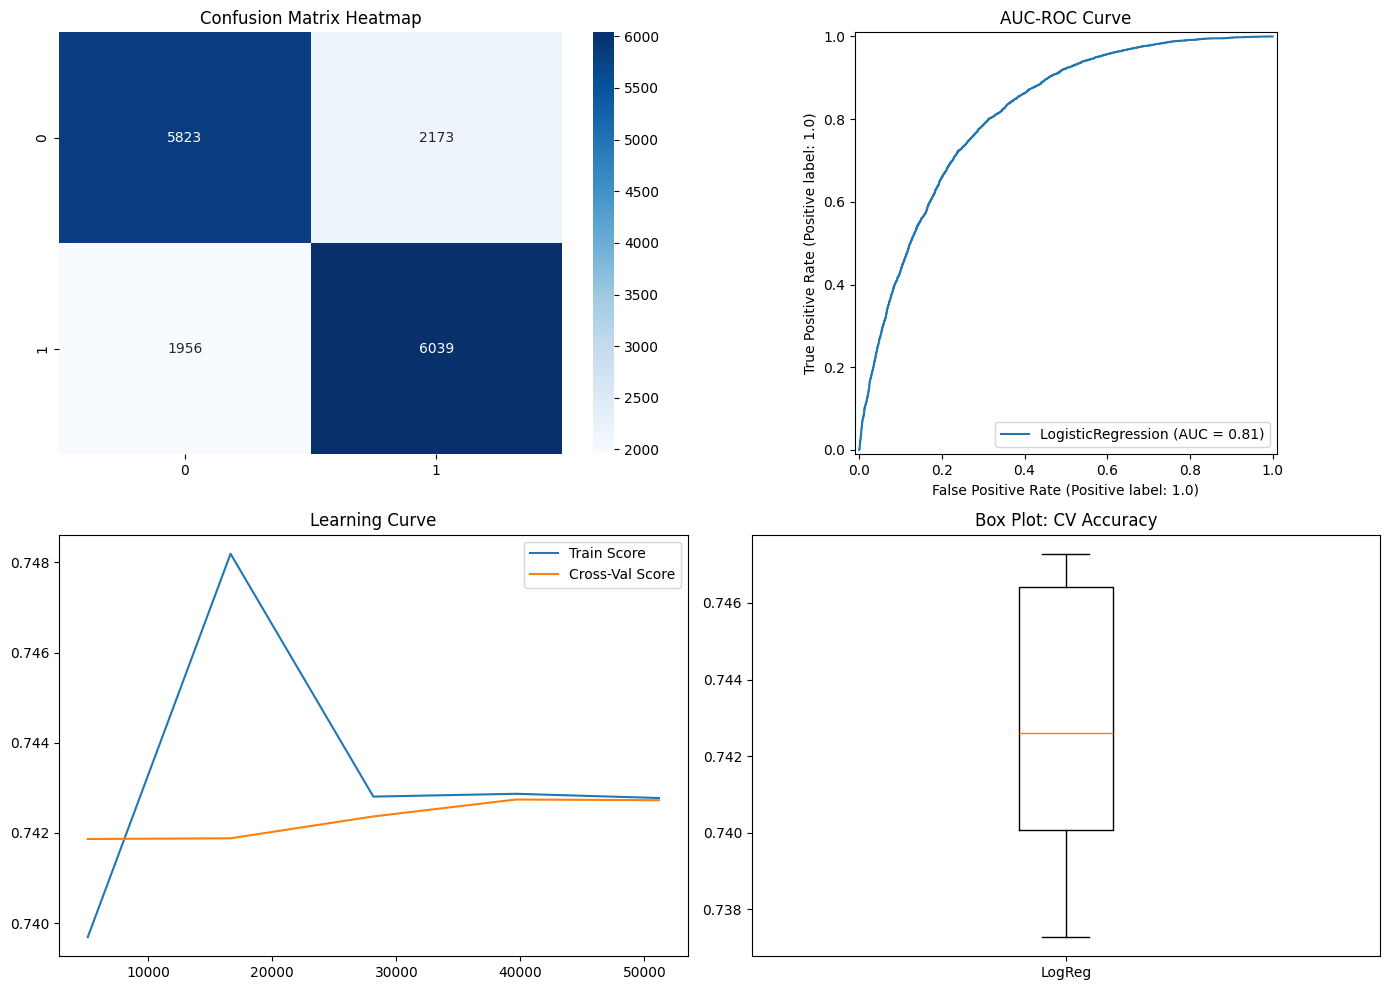

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import learning_curve, cross_val_score

# 1. Initialize and Train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)

print("--- Logistic Regression ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(log_reg, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['LogReg'])

plt.tight_layout()
plt.show()

--- Random Forest ---
Accuracy Score: 0.7420
ROC-AUC Score:  0.8171

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.71      0.73      7996
         1.0       0.73      0.78      0.75      7995

    accuracy                           0.74     15991
   macro avg       0.74      0.74      0.74     15991
weighted avg       0.74      0.74      0.74     15991



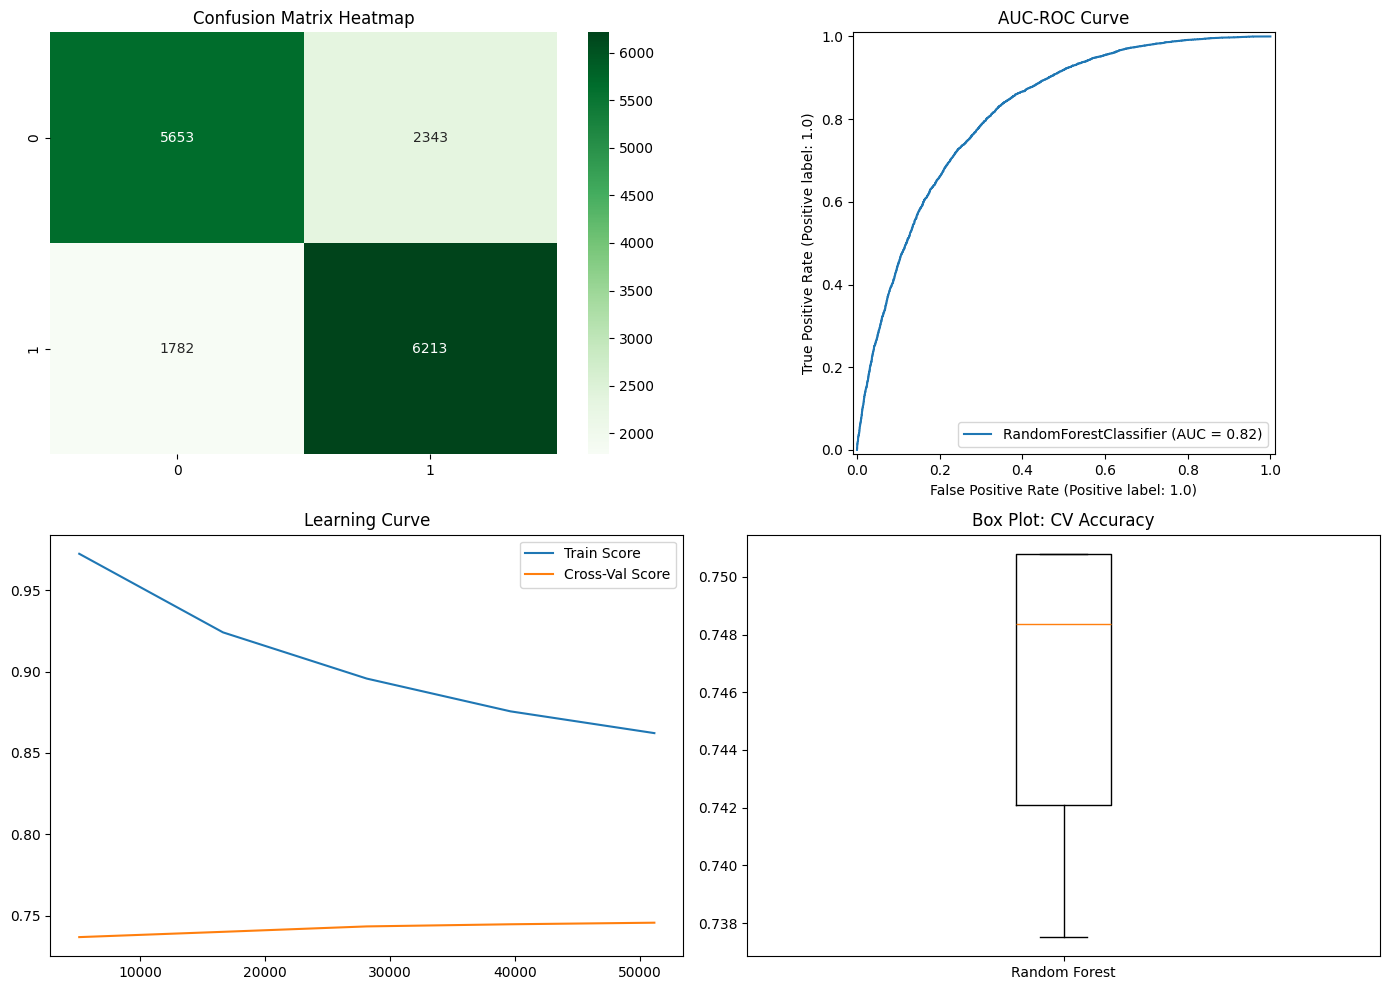

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train (n_jobs=-1 uses all CPU cores for faster training)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)

print("--- Random Forest ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(rf_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['Random Forest'])

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

--- XGBoost ---
Accuracy Score: 0.7402
ROC-AUC Score:  0.8144

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.71      0.73      7996
         1.0       0.72      0.77      0.75      7995

    accuracy                           0.74     15991
   macro avg       0.74      0.74      0.74     15991
weighted avg       0.74      0.74      0.74     15991



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:01:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

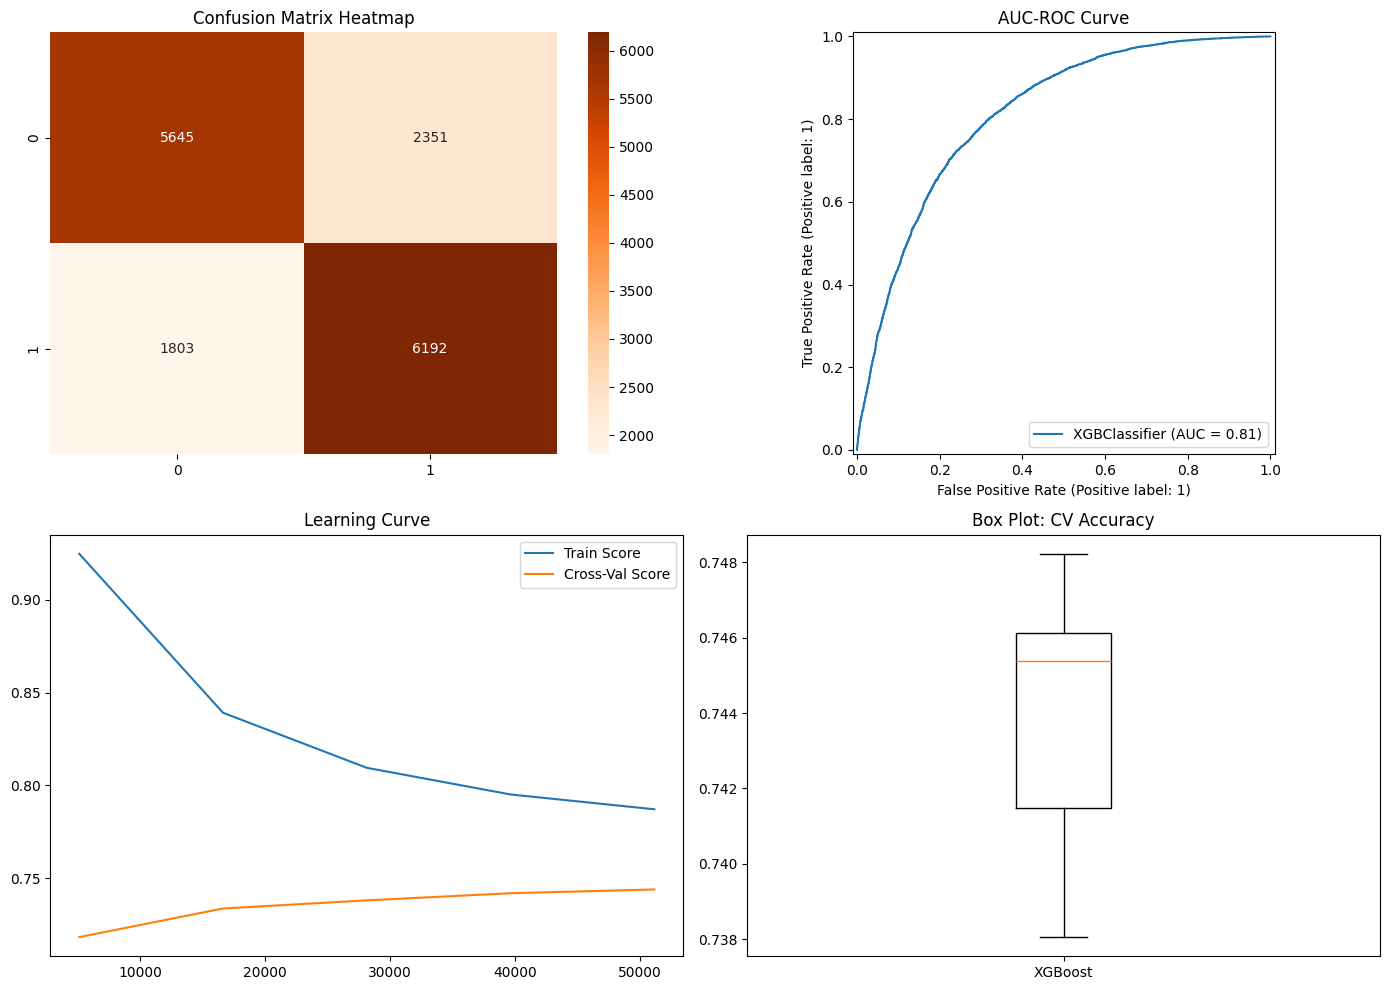

In [ ]:
from xgboost import XGBClassifier

# 1. Initialize and Train
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5)

print("--- XGBoost ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(xgb_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['XGBoost'])

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

--- LightGBM ---
Accuracy Score: 0.7437
ROC-AUC Score:  0.8200

Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.70      0.73      7996
         1.0       0.72      0.79      0.75      7995

    accuracy                           0.74     15991
   macro avg       0.75      0.74      0.74     15991
weighted avg       0.75      0.74      0.74     15991



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

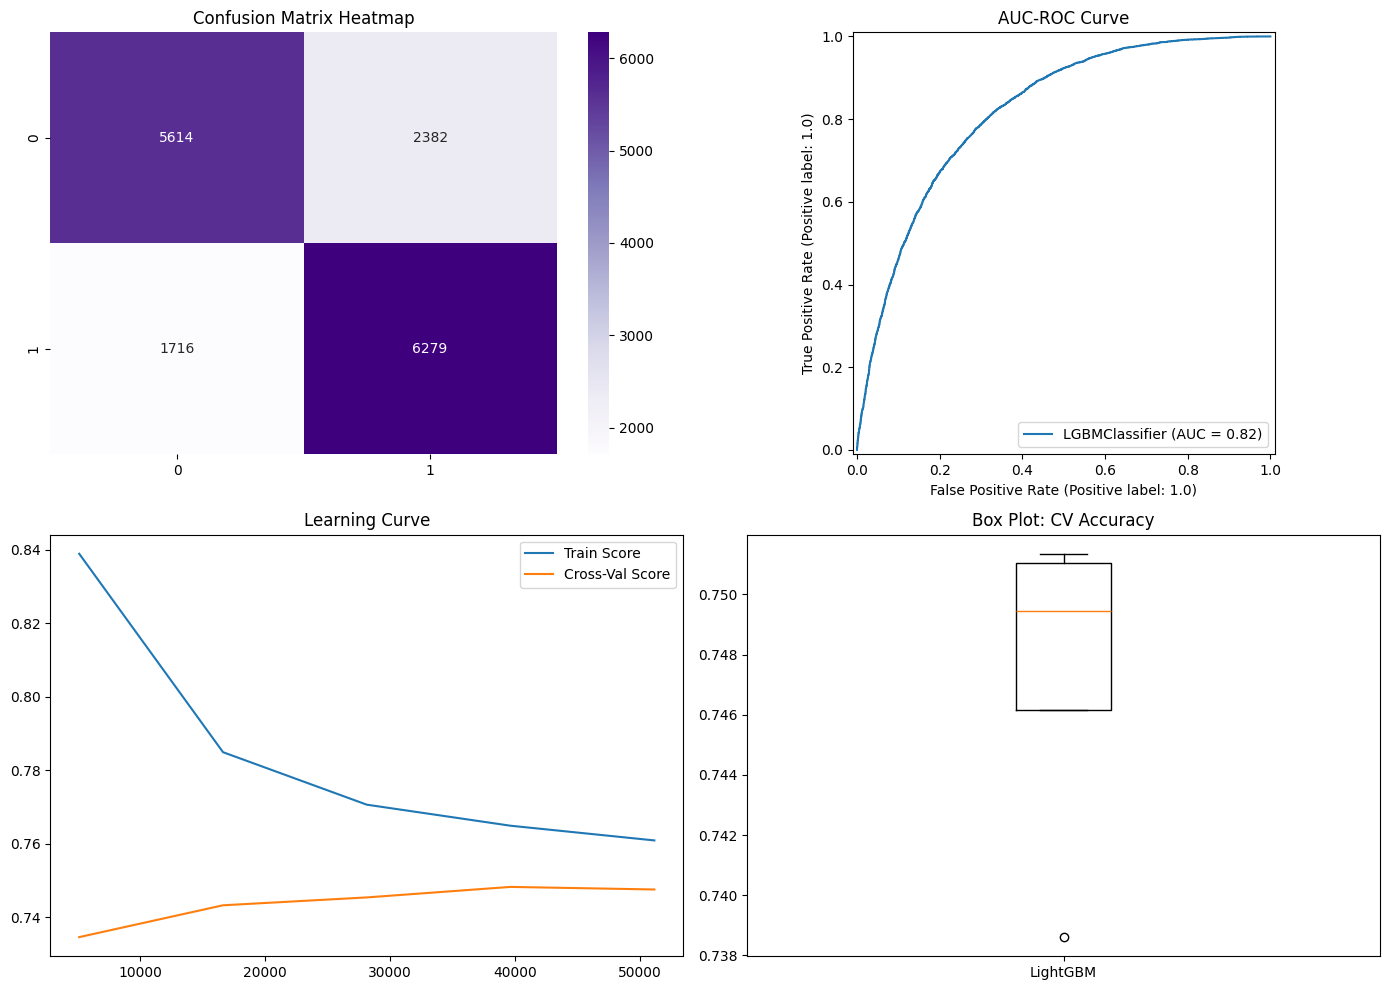

In [ ]:
# Run this cell to ensure LightGBM is installed if it throws an error:
# !pip install lightgbm
from lightgbm import LGBMClassifier

# 1. Initialize and Train
lgbm_model = LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = lgbm_model.predict(X_test_scaled)
y_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(lgbm_model, X_train_scaled, y_train, cv=5)

print("--- LightGBM ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(lgbm_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(lgbm_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['LightGBM'])

plt.tight_layout()
plt.show()

--- K-Nearest Neighbors (KNN) ---
Accuracy Score: 0.7200
ROC-AUC Score:  0.7854

Classification Report:
               precision    recall  f1-score   support

         0.0       0.74      0.68      0.71      7996
         1.0       0.71      0.76      0.73      7995

    accuracy                           0.72     15991
   macro avg       0.72      0.72      0.72     15991
weighted avg       0.72      0.72      0.72     15991



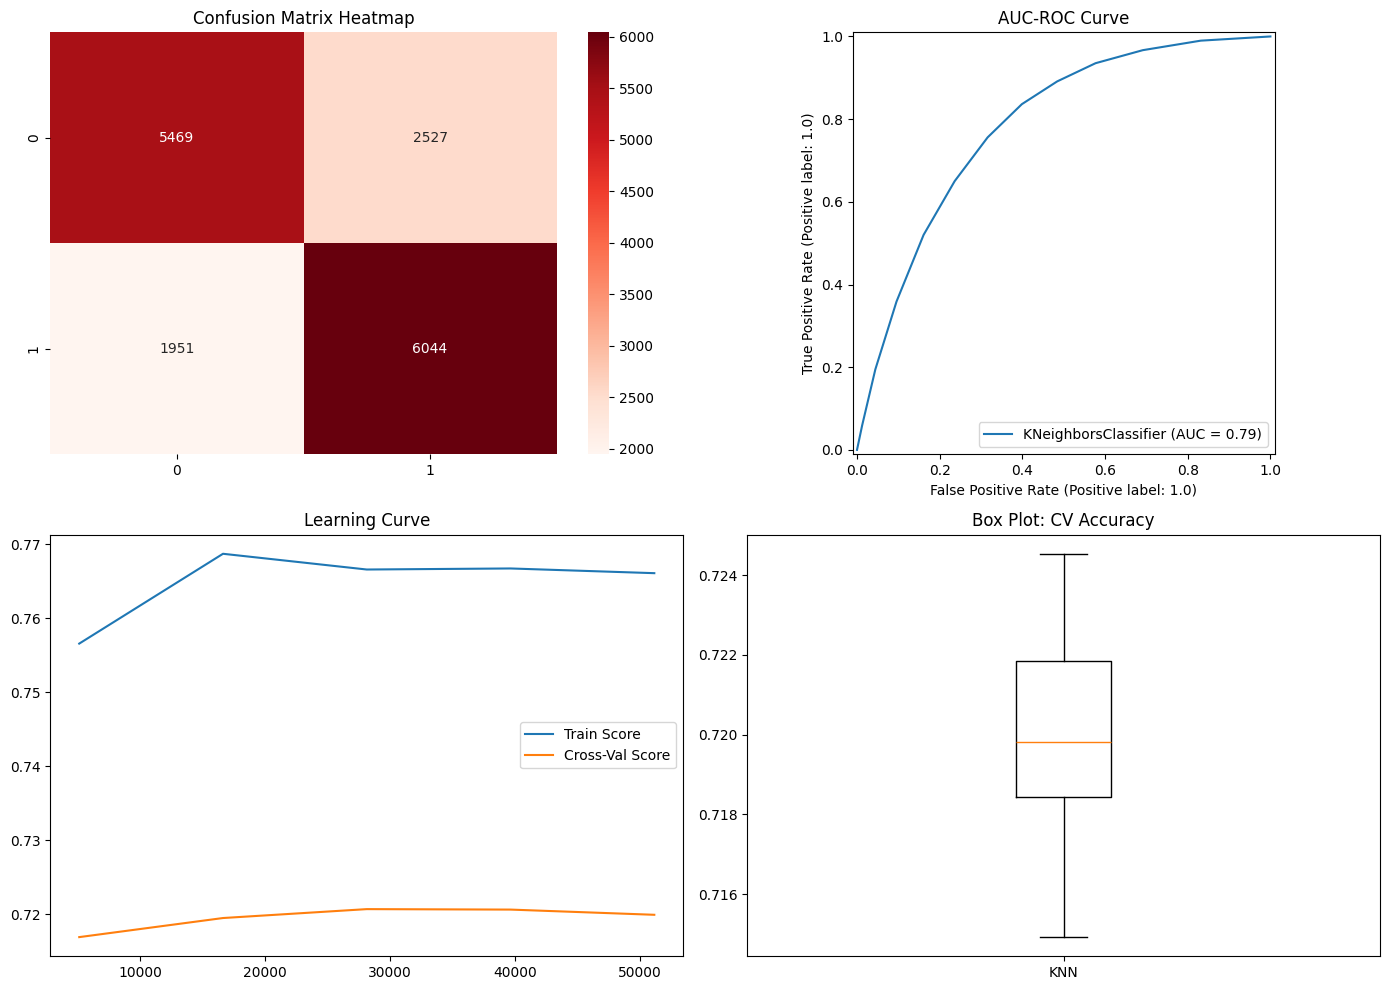

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize and Train (Using k=11 to prevent overfitting on this large dataset)
knn_model = KNeighborsClassifier(n_neighbors=11, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred = knn_model.predict(X_test_scaled)
y_prob = knn_model.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)

print("--- K-Nearest Neighbors (KNN) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix Heatmap")

RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=axes[0, 1])
axes[0, 1].set_title("AUC-ROC Curve")

train_sizes, train_scores, test_scores = learning_curve(knn_model, X_train_scaled, y_train, cv=5)
axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Val Score')
axes[1, 0].set_title("Learning Curve")
axes[1, 0].legend()

axes[1, 1].boxplot(cv_scores)
axes[1, 1].set_title("Box Plot: CV Accuracy")
axes[1, 1].set_xticklabels(['KNN'])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu

# Recombine X_train and y_train temporarily for statistical testing
# (We only test on training data to prevent data leakage)
train_data = X_train.copy()
train_data['Diabetes_binary'] = y_train

print("--- STATISTICAL HYPOTHESIS TESTING ---")
print("Threshold for Significance (Alpha) = 0.05\n")

# 1. CHI-SQUARE TEST (For Categorical Variables)
print("1. Chi-Square Tests (Categorical Features):")
categorical_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'DiffWalk', 'Sex']

for col in categorical_cols:
    # Create a cross-tabulation (contingency table)
    contingency_table = pd.crosstab(train_data[col], train_data['Diabetes_binary'])

    # Run the test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Check significance
    if p_value < 0.05:
        print(f"  [SIGNIFICANT] {col}: p-value = {p_value:.5f} -> Feature is linked to Diabetes.")
    else:
        print(f"  [NOT Significant] {col}: p-value = {p_value:.5f} -> Feature is NOT linked to Diabetes.")

print("\n--------------------------------------------------\n")

# 2. MANN-WHITNEY U TEST (For Continuous/Ordinal Variables)
print("2. Mann-Whitney U Tests (Continuous/Ordinal Features):")
continuous_cols = ['BMI', 'PhysHlth', 'MentHlth', 'Age', 'Education', 'Income']

# Split groups
diabetics = train_data[train_data['Diabetes_binary'] == 1.0]
healthy = train_data[train_data['Diabetes_binary'] == 0.0]

for col in continuous_cols:
    # Run the test
    stat, p_value = mannwhitneyu(diabetics[col], healthy[col], alternative='two-sided')

    # Check significance
    if p_value < 0.05:
        print(f"  [SIGNIFICANT] {col}: p-value = {p_value:.5f} -> Feature is linked to Diabetes.")
    else:
        print(f"  [NOT Significant] {col}: p-value = {p_value:.5f} -> Feature is NOT linked to Diabetes.")

--- STATISTICAL HYPOTHESIS TESTING ---
Threshold for Significance (Alpha) = 0.05

1. Chi-Square Tests (Categorical Features):
  [SIGNIFICANT] HighBP: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] HighChol: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] Smoker: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] Stroke: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] HeartDiseaseorAttack: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] DiffWalk: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] Sex: p-value = 0.00000 -> Feature is linked to Diabetes.

--------------------------------------------------

2. Mann-Whitney U Tests (Continuous/Ordinal Features):
  [SIGNIFICANT] BMI: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] PhysHlth: p-value = 0.00000 -> Feature is linked to Diabetes.
  [SIGNIFICANT] MentHlth: p-value = 0.00000 -> Feature is linked to 

Starting Hybrid Model Training... This may take a few minutes.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Completed in 0.90 minutes!

--- Hybrid Stacking Model Evaluation ---
Accuracy Score: 0.7445
ROC-AUC Score:  0.8209

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.72      0.74      7996
         1.0       0.73      0.77      0.75      7995

    accuracy                           0.74     15991
   macro avg       0.75      0.74      0.74     15991
weighted avg       0.75      0.74      0.74     15991



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


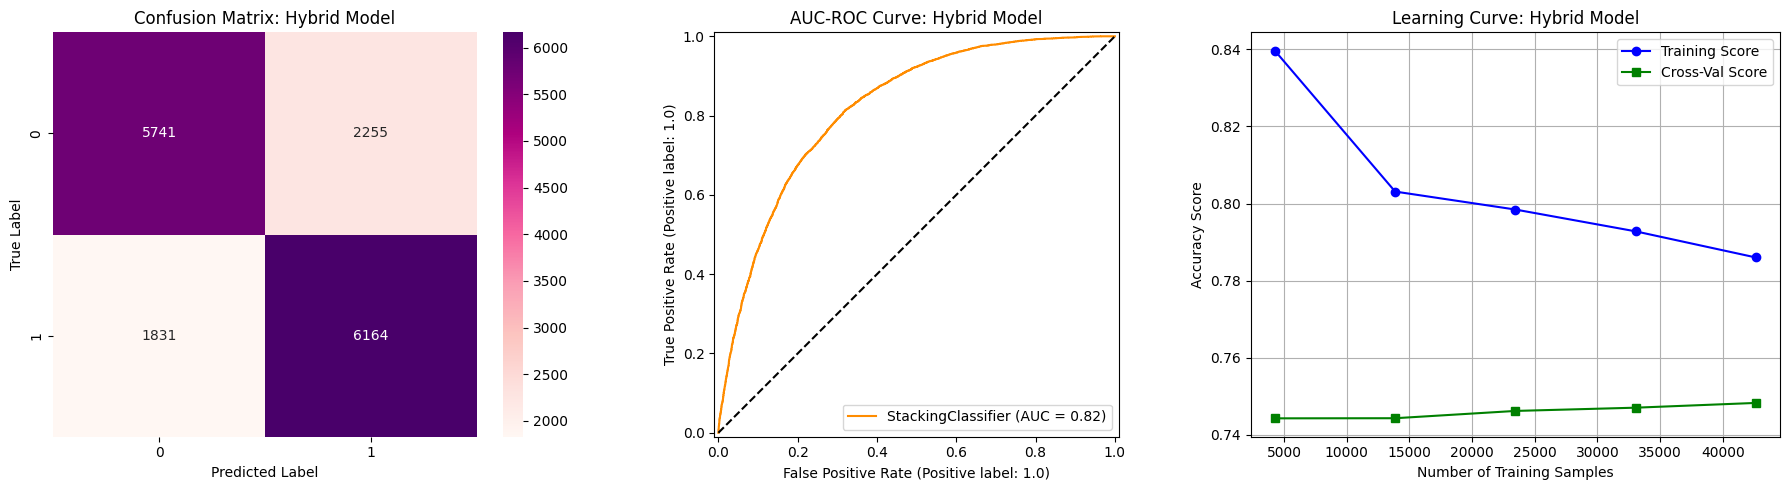

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import learning_curve, cross_val_score
import time

print("Starting Hybrid Model Training... This may take a few minutes.\n")
start_time = time.time()

# 1. Define the Base Models (The "Level 0" learners)
# We are leaving out KNN to save training time, as the tree models + LogReg are stronger.
base_models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1))
]

# 2. Define the Meta-Model (The "Level 1" learner that makes the final decision)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# 3. Initialize and Train the Stacking Classifier
hybrid_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)
hybrid_model.fit(X_train_scaled, y_train)

# 4. Predictions & Metrics
y_pred = hybrid_model.predict(X_test_scaled)
y_prob = hybrid_model.predict_proba(X_test_scaled)[:, 1]

# Note: We skip the cross_val_score step here because Stacking is already incredibly computationally heavy.
# The Accuracy and ROC-AUC on the test set will be our primary indicators.

end_time = time.time()
print(f"Training Completed in {(end_time - start_time)/60:.2f} minutes!")
print("\n--- Hybrid Stacking Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Visualization 1: Confusion Matrix Heatmap ---
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu', ax=axes[0])
axes[0].set_title("Confusion Matrix: Hybrid Model")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# --- Visualization 2: AUC-ROC Curve ---
RocCurveDisplay.from_estimator(hybrid_model, X_test_scaled, y_test, ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--') # Add diagonal line for reference
axes[1].set_title("AUC-ROC Curve: Hybrid Model")

# --- Visualization 3: Learning Curve ---
# We use a smaller cv=3 here to speed up the learning curve rendering
train_sizes, train_scores, test_scores = learning_curve(
    hybrid_model, X_train_scaled, y_train, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)
axes[2].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score', color='blue')
axes[2].plot(train_sizes, np.mean(test_scores, axis=1), 's-', label='Cross-Val Score', color='green')
axes[2].set_title("Learning Curve: Hybrid Model")
axes[2].set_xlabel("Number of Training Samples")
axes[2].set_ylabel("Accuracy Score")
axes[2].legend(loc="best")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Run this in your DIABETES Notebook
joblib.dump(hybrid_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')

['diabetes_scaler.pkl']

In [ ]:
# import joblib
# from google.colab import files

# # 1. Save the model and scaler to Colab's temporary memory
# joblib.dump(hybrid_model, 'diabetes_model.pkl')
# joblib.dump(scaler, 'diabetes_scaler.pkl')
# print("Diabetes files saved to Colab. Starting download to your computer...")

# # 2. Force the browser to download them directly to your computer
# files.download('diabetes_model.pkl')
# files.download('diabetes_scaler.pkl')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
from google.colab import files

print("1. Downloading the strict 8-feature dataset...")
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

joblib.dump(model, 'diabetes_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')

files.download('diabetes_model.pkl')
files.download('diabetes_scaler.pkl')

1. Downloading the strict 8-feature dataset...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# 1. Have the AI predict all test cases
# Re-scale X_test from the Pima dataset using the Pima scaler
X_test_scaled_pima = scaler.transform(X_test) # Use the X_test and scaler from UR-1RvsyQXZ4

predictions = model.predict(X_test_scaled_pima) # Use the correctly scaled test data

# 2. Find ONLY the patients where the AI guessed correctly!
# Ensure y_test also corresponds to the Pima dataset
correct_patients = X_test[predictions == y_test]
correct_labels = y_test[predictions == y_test]

# 3. Separate them into Low Risk (0) and High Risk (1)
low_risk_patients = correct_patients[correct_labels == 0]
high_risk_patients = correct_patients[correct_labels == 1]

# 4. Grab exactly 2 guaranteed correct patients of each type
patient_1_low = low_risk_patients.iloc[[0]]
patient_2_low = low_risk_patients.iloc[[1]]
patient_3_high = high_risk_patients.iloc[[0]]
patient_4_high = high_risk_patients.iloc[[1]]

# 5. Save and Download
patient_1_low.to_csv('Diabetes_LowRisk_1.csv', index=False)
patient_2_low.to_csv('Diabetes_LowRisk_2.csv', index=False)
patient_3_high.to_csv('Diabetes_HighRisk_1.csv', index=False)
patient_4_high.to_csv('Diabetes_HighRisk_2.csv', index=False)

files.download('Diabetes_LowRisk_1.csv')
files.download('Diabetes_LowRisk_2.csv')
files.download('Diabetes_HighRisk_1.csv')
files.download('Diabetes_HighRisk_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>